In [22]:
# Cell 1 - Install libraries
!pip install boto3 psycopg2-binary pandas scikit-learn xgboost sqlalchemy

In [37]:
# Cell 2 - Credentials Setup
import boto3
from sqlalchemy import create_engine

# AWS Credentials
AWS_ACCESS_KEY = "your_access_key_here"
AWS_SECRET_KEY = "your_secret_key_here"
AWS_BUCKET = "hospital-readmission-zenith"
AWS_REGION = "ap-south-1"

# Supabase PostgreSQL
DB_URL = "your_database_url_here"

# Test connections
s3 = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)

engine = create_engine(DB_URL)

print("S3 Connected ✅")
print("Database Connected ✅")

S3 Connected ✅
Database Connected ✅


In [38]:
# Cell 3 - Reload Dataset
import pandas as pd

df = pd.read_csv('/content/diabetic_data.csv')
print("Shape:", df.shape)

Shape: (101766, 50)


In [39]:
# Cell 4 - Data Cleaning (Fixed)
import numpy as np

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop only high-null columns
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Drop duplicates (same patient, keep first)
df.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)

# Target column
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Fill missing values instead of dropping
df['race'].fillna('Unknown', inplace=True)
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

print("Cleaned Shape:", df.shape)
print("Readmission Rate:", round(df['readmitted'].mean() * 100, 2), "%")

Cleaned Shape: (71518, 47)
Readmission Rate: 8.8 %


/tmp/ipykernel_22675/2814019577.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
/tmp/ipykernel_22675/2814019577.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [40]:
# Cell 5 - Save to PostgreSQL
df.to_sql('readmissions', engine, if_exists='replace', index=False)

print(f"Data saved to PostgreSQL ✅")
print(f"Total rows: {len(df)}")

Data saved to PostgreSQL ✅
Total rows: 71518


In [41]:
# Cell 6 - Upload CSV to S3
df.to_csv('readmission_data.csv', index=False)

s3.upload_file(
    'readmission_data.csv',
    AWS_BUCKET,
    'data/readmission_data.csv'
)

print("Data uploaded to S3 ✅")
print(f"Bucket: {AWS_BUCKET}")
print(f"File: data/readmission_data.csv")

Data uploaded to S3 ✅
Bucket: hospital-readmission-zenith
File: data/readmission_data.csv


In [43]:
# Cell 7 - ML Model (Fixed with SMOTE)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Install imbalanced-learn
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])

features = ['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures',
            'num_procedures', 'num_medications', 'number_outpatient',
            'number_emergency', 'number_inpatient', 'number_diagnoses']

X = df[features].copy()
y = df['readmitted']

# Encode categorical columns
le = LabelEncoder()
for col in ['race', 'gender', 'age']:
    X[col] = le.fit_transform(X[col].astype(str))

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE - balance the data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, y_prob), 4)}")

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     13140
           1       0.10      0.16      0.12      1164

    accuracy                           0.81     14304
   macro avg       0.51      0.51      0.51     14304
weighted avg       0.85      0.81      0.83     14304

ROC-AUC Score: 0.5295


In [44]:
# Cell 8 - Save Model to S3
import pickle

# Save model locally
with open('readmission_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Upload to S3
s3.upload_file(
    'readmission_model.pkl',
    AWS_BUCKET,
    'models/readmission_model.pkl'
)

print("Model saved to S3 ✅")
print(f"Bucket: {AWS_BUCKET}")
print(f"File: models/readmission_model.pkl")

Model saved to S3 ✅
Bucket: hospital-readmission-zenith
File: models/readmission_model.pkl


In [45]:
# Cell 9 - SQL Analysis Queries
import pandas as pd

# Query 1 - Readmission rate by age group
q1 = pd.read_sql("""
    SELECT age,
           COUNT(*) as total_patients,
           SUM(readmitted) as readmitted_count,
           ROUND(AVG(readmitted::numeric) * 100, 2) as readmission_rate
    FROM readmissions
    GROUP BY age
    ORDER BY readmission_rate DESC
    LIMIT 10
""", engine)

print("=== Readmission Rate by Age Group ===")
print(q1)

# Query 2 - Readmission by diagnosis
q2 = pd.read_sql("""
    SELECT diag_1,
           COUNT(*) as total,
           SUM(readmitted) as readmitted_count,
           ROUND(AVG(readmitted::numeric) * 100, 2) as readmission_rate
    FROM readmissions
    GROUP BY diag_1
    ORDER BY readmission_rate DESC
    LIMIT 10
""", engine)

print("\n=== Top Diagnoses with High Readmission ===")
print(q2)

# Query 3 - Average hospital stay for readmitted vs non-readmitted
q3 = pd.read_sql("""
    SELECT readmitted,
           ROUND(AVG(time_in_hospital), 2) as avg_stay,
           COUNT(*) as total
    FROM readmissions
    GROUP BY readmitted
""", engine)

print("\n=== Avg Hospital Stay: Readmitted vs Not ===")
print(q3)

=== Readmission Rate by Age Group ===
        age  total_patients  readmitted_count  readmission_rate
0   [80-90)           11589            1201.0             10.36
1   [70-80)           18210            1824.0             10.02
2   [60-70)           15960            1414.0              8.86
3  [90-100)            1900             168.0              8.84
4   [40-50)            6878             507.0              7.37
5   [20-30)            1127              83.0              7.36
6   [50-60)           12466             879.0              7.05
7   [30-40)            2699             188.0              6.97
8   [10-20)             535              26.0              4.86
9    [0-10)             154               3.0              1.95

=== Top Diagnoses with High Readmission ===
  diag_1  total  readmitted_count  readmission_rate
0    906      1               1.0            100.00
1    347      1               1.0            100.00
2    904      1               1.0            100.00
3    

Visualization saved & uploaded to S3 ✅


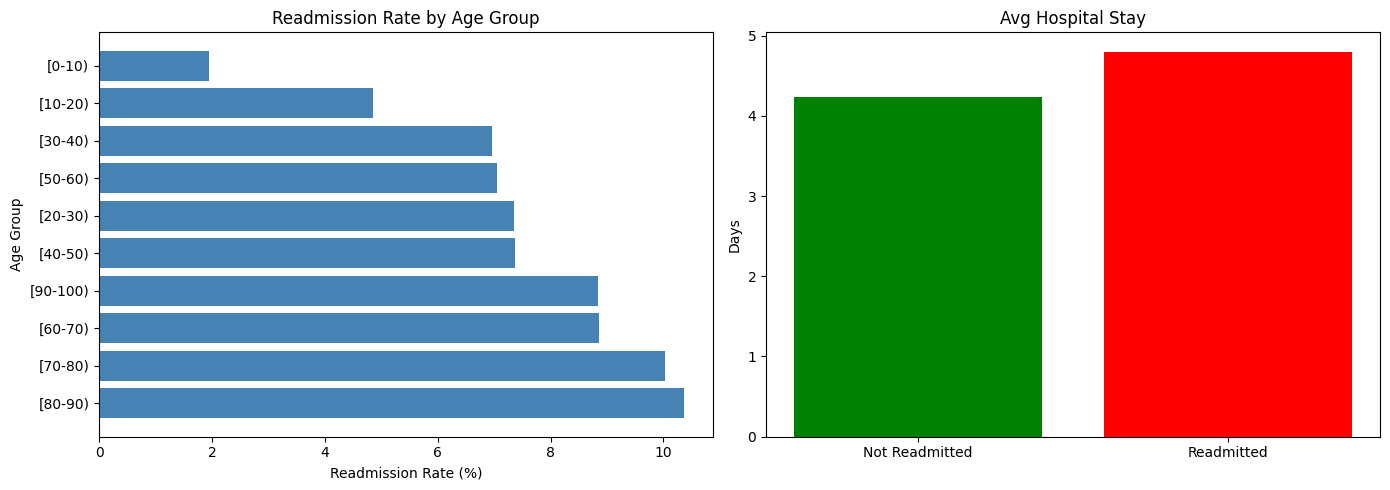

In [46]:
# Cell 10 - Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Readmission rate by age
axes[0].barh(q1['age'], q1['readmission_rate'], color='steelblue')
axes[0].set_title('Readmission Rate by Age Group')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].set_ylabel('Age Group')

# Plot 2 - Avg stay comparison
axes[1].bar(['Not Readmitted', 'Readmitted'], q3['avg_stay'], color=['green', 'red'])
axes[1].set_title('Avg Hospital Stay')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('readmission_analysis.png')

# Upload visualization to S3
s3.upload_file('readmission_analysis.png', AWS_BUCKET, 'plots/readmission_analysis.png')

print("Visualization saved & uploaded to S3 ✅")
plt.show()